<a href="https://colab.research.google.com/github/dhunsyam/Advance-Databases/blob/gh-pages/notebooks/Activity%3A%20Time%20series%20models%E2%80%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

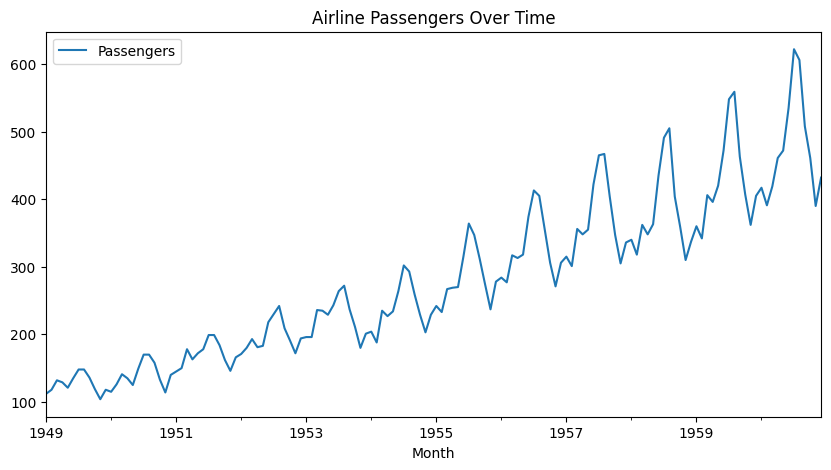

622
104
            Passengers
Month                 
1949-01-01         112
            Passengers
Month                 
1960-12-01         432


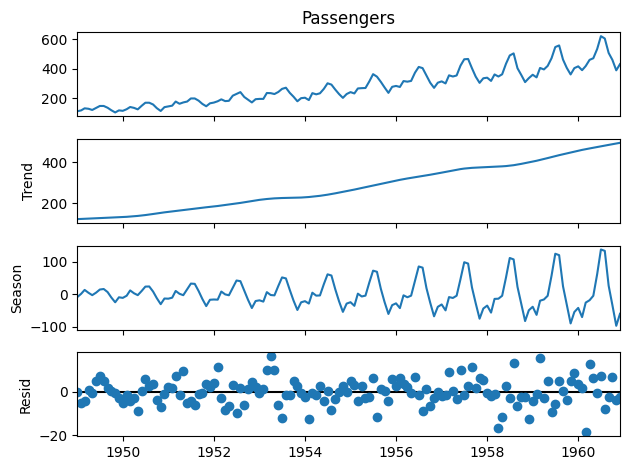

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


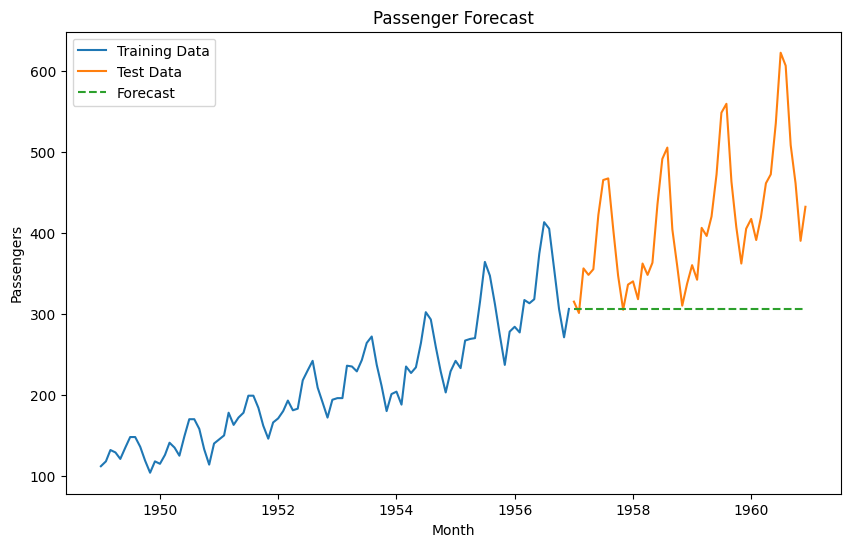

RMSE on test data: 132.61


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [8]:
!pip install pmdarima

import pandas as pd

import matplotlib.pyplot as plt

#Load the data

#Load the dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

df.plot(figsize=(10, 5), title='Airline Passengers Over Time')

plt.show()

max = df['Passengers'].max()

print(max)

min = df['Passengers'].min()

print(min)

print(df.head(1))

print(df.tail(1))

from statsmodels.tsa.seasonal import STL

#Perform STL decomposition

stl = STL(df['Passengers'], seasonal=13)

result = stl.fit()

#Plot the decomposition

result.plot()

plt.show()


import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing



# Split data into train and test (last 12 months for testing)

train = df[:-48]

test = df[-48:]

#Fit models on training data

model = ExponentialSmoothing(

    train['Passengers'],

    trend=None,

    seasonal=None,

    seasonal_periods=12

).fit()

#Make forecast for test period

forecast = model.forecast(len(test))

#Plot everything

plt.figure(figsize=(10, 6))

plt.plot(train['Passengers'], label='Training Data')

plt.plot(test['Passengers'], label='Test Data')

plt.plot(test.index, forecast, label='Forecast', linestyle='--')

plt.title('Passenger Forecast')

plt.xlabel('Month')

plt.ylabel('Passengers')

plt.legend()

plt.show()

#Print accuracy for test period

from sklearn.metrics import mean_squared_error

import numpy as np

rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))

print(f'RMSE on test data: {rmse:.2f}')




import pmdarima as pm

import warnings

import pandas as pd

import logging

warnings.filterwarnings("ignore", category=FutureWarning)



#Fit Auto ARIMA with detailed logging

model = pm.auto_arima(

    df['Passengers'],

    seasonal=True,

    m=12,  # Monthly data (seasonality=12 months)

    stepwise=True,

    suppress_warnings=True,  # Allow warnings to see potential issues

    trace=True,  # Enables logging of each model tested

    error_action='ignore',  # Ignore errors to keep process going

    maxiter=100  # Ensure enough iterations to log multiple models

)

#Print Summary of the Best Model

print(model.summary())






import pmdarima as pm

import warnings

import pandas as pd

import logging

import matplotlib.pyplot as plt

import numpy as np

from sklearn.metrics import mean_squared_error

#Ignore warnings

warnings.filterwarnings("ignore", category=FutureWarning)



# Split Data: Train = all except last 48 months, Test = last 48 months

train = df.iloc[:-48]

test = df.iloc[-48:]

#Fit Auto ARIMA on Training Data

model = pm.auto_arima(

    train['Passengers'],

    seasonal=True,

    m=12,  # Monthly data (seasonality=12 months)

    stepwise=True,

    suppress_warnings=True,

    trace=True,  # Enables logging of each model tested

    error_action='ignore',

    maxiter=100  # Ensure enough iterations to log multiple models

)

#Print Summary of the Best Model

print(model.summary())



# Forecast the last 48 months (same period as test data)

forecast, conf_int = model.predict(n_periods=48, return_conf_int=True)

#Plot actual vs forecast

plt.figure(figsize=(10, 5))

plt.plot(df.index, df['Passengers'], label='Actual Data', color='blue')

plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='dashed')

plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)

plt.title('Passenger Forecast vs Actual (Last 48 Months)')

plt.xlabel('Month')

plt.ylabel('Passengers')

plt.legend()

plt.show()

#Calculate RMSE for evaluation

rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))

print(f'RMSE on test data: {rmse:.2f}')